# CHECKLIST:
# [ ] Runway clearly visible
# [ ] Geometry preserved (straight lines)
# [ ] Not overly distorted
# [ ] Background still realistic

In [ ]:
from PIL import Image
import os
import sys
import random
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

sys.path.append('../scripts/data_utils')
from data_transforms import train_transforms, validate_transforms

train_directory = "../data/TrainSet"
val_directory = "../data/ValidationSet"

def safe_sample(file_list, k=5):
    return random.sample(file_list, min(len(file_list), k))


# 5 random images
runway_files = safe_sample(os.listdir(os.path.join(train_directory, 'runway')))
no_runway_files = safe_sample(os.listdir(os.path.join(train_directory, 'no_runway')))
runway_images = [os.path.join(train_directory, 'runway', f) for f in runway_files]
no_runway_images = [os.path.join(train_directory, 'no_runway', f) for f in no_runway_files]
val_runway_files = random.sample(os.listdir(os.path.join(val_directory, "runway")), 5)
val_no_runway_files = random.sample(os.listdir(os.path.join(val_directory, "no_runway")), 5)
val_runway_images = [os.path.join(val_directory, "runway", f) for f in val_runway_files]
val_no_runway_images = [os.path.join(val_directory, "no_runway", f) for f in val_no_runway_files]

def apply_transforms(image_paths, transform):
    transformed_images = []
    for path in image_paths:
        image = Image.open(path).convert('RGB')
        transformed_image = transform(image)
        transformed_images.append(transformed_image)
    return transformed_images

transformed_runway_images_train = apply_transforms(runway_images, train_transforms)
transformed_no_runway_images_train = apply_transforms(no_runway_images, train_transforms)
transformed_runway_images_val = apply_transforms(val_runway_images, validate_transforms)
transformed_no_runway_images_val = apply_transforms(val_no_runway_images, validate_transforms)


# Displaying the transformed images

def display_images(transformed_images, title):
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    selected_images = random.sample(
        transformed_images,
        min(5, len(transformed_images))
    )

    plt.figure(figsize=(12, 4))

    for i, img in enumerate(selected_images):
        plt.subplot(1, len(selected_images), i + 1)

        img_denorm = inv_normalize(img).clamp(0, 1)
        img_np = img_denorm.permute(1, 2, 0).numpy()

        plt.imshow(img_np)
        plt.axis('off')

    plt.suptitle(title)
    plt.show()



Viewing the effects of the augmentations on 5 random images.

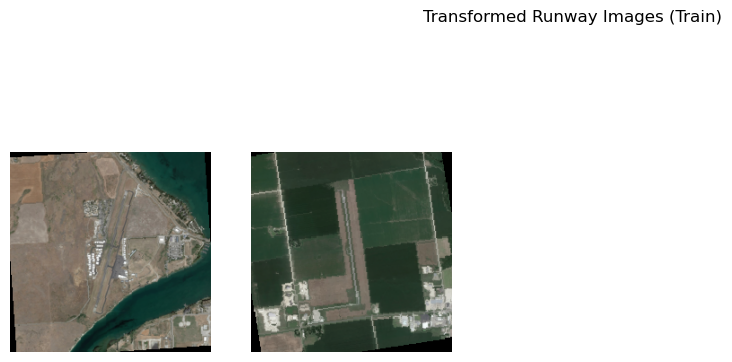

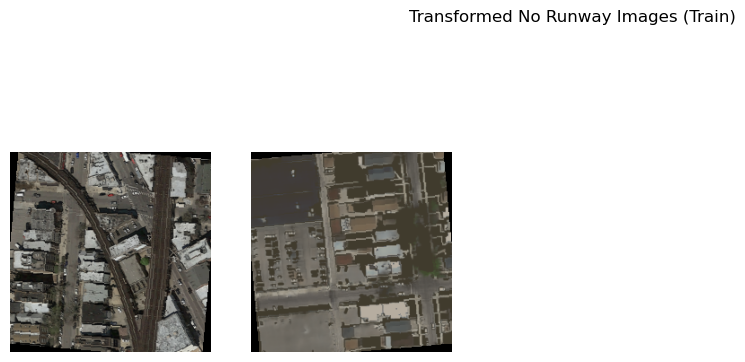

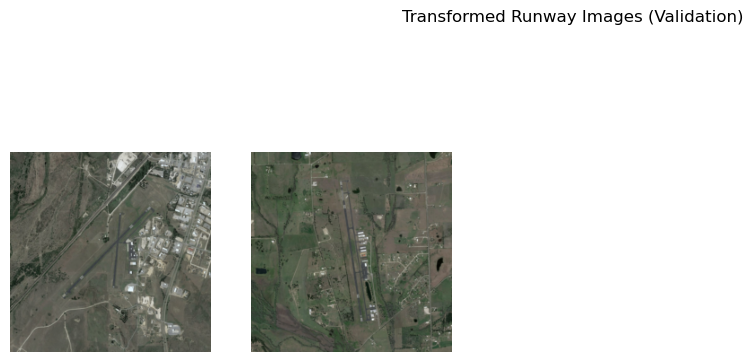

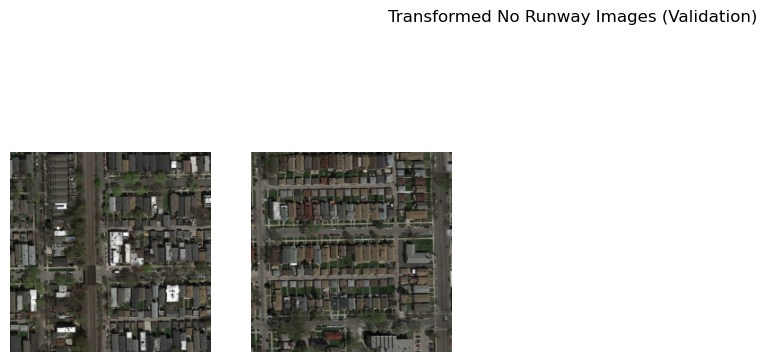

In [11]:
display_images(transformed_runway_images_train, "Transformed Runway Images (Train)")
display_images(transformed_no_runway_images_train, "Transformed No Runway Images (Train)")
display_images(transformed_runway_images_val, "Transformed Runway Images (Validation)")
display_images(transformed_no_runway_images_val, "Transformed No Runway Images (Validation)")

Show mulitple augmentations of the same image.

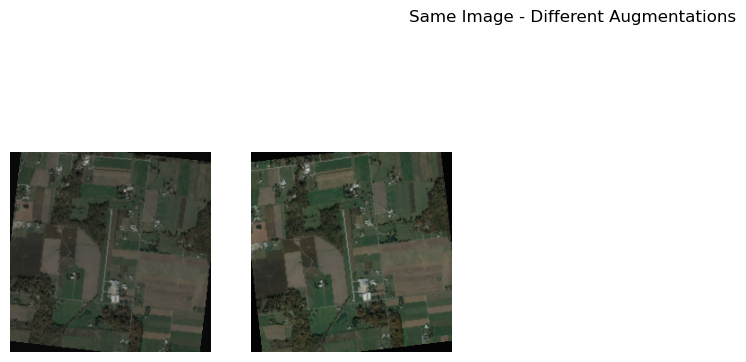

In [12]:
image_path = runway_images[0]

imgs = apply_transforms([image_path]*5, train_transforms)
display_images(imgs, "Same Image - Different Augmentations")

TypeError: img should be Tensor Image. Got <class 'list'>

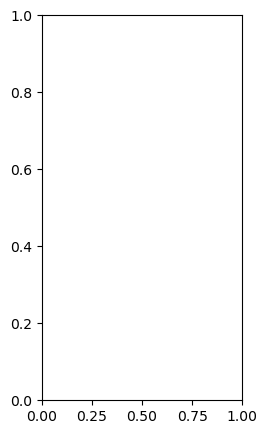

In [ ]:
img_path = runway_images[0]

train_img = apply_transforms([img_path], train_transforms)[0]
val_img = apply_transforms([img_path], validate_transforms)[0]

display_images([train_img, val_img], "Train vs Validation")

In [ ]:
#